In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import lines as mlines

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV, SelectKBest, f_regression, mutual_info_regression, RFE, GenericUnivariateSelect, SelectPercentile
from sklearn.model_selection import KFold, train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

### KNNR + Hyperparameter tuning 

Load the data, the spreadsheet contains the features and the target variable (ddG) for each ligand for case study II.

In [2]:
df = pd.read_excel('../fluoride_modeling_properties_w_experimental_data.xlsx',
                   sheet_name='CS2_combined_ddg', header=1)

df.head(5)

,substrate1_smiles,substrate2_smiles,product smiles,ligandID,set,ligand_smiles,yield,ee,ddg,ddg_flipped,...,aniso_NMR_shift_N1_low_E,NMR_shift_N2_Boltz,NMR_shift_N2_min,NMR_shift_N2_max,NMR_shift_N2_low_E,aniso_NMR_shift_N2_Boltz,aniso_NMR_shift_N2_min,aniso_NMR_shift_N2_max,aniso_NMR_shift_N2_low_E,rxn
0,FC1=CC=C(C2CN2S(C3=CC=C(C)C=C3)(=O)=O)C=C1,O=C(Cl)CCC1=CC=C(OC)C=C1,O=C(CCC1=CC=C(OC)C=C1)C(CNS(C2=CC=C(C)C=C2)(=O...,32,test,CC([C@H]1CN2C(C3=N[C@@H](C(C)C)CN3CC2)=N1)C,13,2,0.023700,-0.023700,...,512.6748,-14.404550,-43.0958,15.0975,-34.0742,533.196396,497.1786,601.3179,512.9865,1
1,CC(Cl)C1=CC=CC=C4,O=C(Cl)CCC1=CC=C(OC)C=C4,O=C([C@@H](C)C1=CC=CC=C1)CCC2=CC=C(OC)C=C5,32,test,CC(C)[C@@H]1N=C2C3=N[C@@H](C(C)C)CN3CCN2C1,20,2,0.023700,-0.023700,...,512.6748,-14.404550,-43.0958,15.0975,-34.0742,533.196396,497.1786,601.3179,512.9865,0
2,FC1=CC=C(C2CN2S(C3=CC=C(C)C=C3)(=O)=O)C=C1,O=C(Cl)CCC1=CC=C(OC)C=C1,O=C(CCC1=CC=C(OC)C=C1)C(CNS(C2=CC=C(C)C=C2)(=O...,33,test,CC([C@H]1COC(C2(CCC2)C3=N[C@@H](C(C)(C)C)CO3)=...,17,1,0.011849,-0.011849,...,659.4930,93.034519,-95.7020,179.5535,99.9378,550.432414,157.9218,1539.6585,533.7808,1
3,CC(Cl)C1=CC=CC=C5,O=C(Cl)CCC1=CC=C(OC)C=C5,O=C([C@@H](C)C1=CC=CC=C1)CCC2=CC=C(OC)C=C6,33,test,CC([C@H]1COC(C2(CCC2)C3=N[C@@H](C(C)(C)C)CO3)=...,38,0,0.000000,0.000000,...,659.4930,93.034519,-95.7020,179.5535,99.9378,550.432414,157.9218,1539.6585,533.7808,0
4,FC1=CC=C(C2CN2S(C3=CC=C(C)C=C3)(=O)=O)C=C1,O=C(Cl)CCC1=CC=C(OC)C=C1,O=C(CCC1=CC=C(OC)C=C1)C(CNS(C2=CC=C(C)C=C2)(=O...,34,test,CC(C)[C@@H](CO1)N=C1C2=CC=C(C=CC=C3)C3=N2,22,24,0.290020,-0.290020,...,555.0980,203.054245,-300.4744,265.8757,225.2275,375.520180,235.3947,824.5443,281.9285,1


Train|Validation|Test is done on the basis of the set column in the spreadsheet (y-equidistant sampling).

### Preprocessing of the features

In [3]:
def list_correlated_features_to_remove(df, threshold):
    """List a set of correlated features to remove based on a threshold, keeps one element of each correlated pair."""
    df_num = df.select_dtypes(include=[np.number])  # Select only numeric columns
    corr = df_num.corr().abs()
    to_drop = set()
    for i, col1 in enumerate(df_num.columns):
        for col2 in df_num.columns[i+1:]:
            if corr.loc[col1, col2] > threshold:
                to_drop.add(col2)  # Keep col1, drop col2

    to_keep = [col for col in df_num.columns if col not in to_drop]
    return to_drop, to_keep

def get_Xy_train_val_test(df_exp, df_features_scaled):
    df_scaled = pd.concat([df_exp.reset_index(drop=True), df_features_scaled.reset_index(drop=True)], axis=1)
    X = df_features_scaled
    y = (df_scaled['ddg_flipped'])
    y = pd.to_numeric(y, errors='coerce').astype(float)
    y_labels = df_scaled['ligandID']
    return X, y, y_labels

def preprocess_data(df, threshold=None, scaler=None, silent=False):
    """Preprocess the data by removing collinear features and standardizing the features.
    Args:
        df (pd.DataFrame): The input dataframe containing the features and target variable.
        threshold (float): The threshold for removing collinear features based on R^2, if threshold is None, no features will be removed.
        scaler (sklearn.preprocessing.StandardScaler): The scaler to standardize the features.
    Returns:
        X_train (pd.DataFrame): The preprocessed training features.
        y_train (pd.Series): The target variable for the training set.
        y_train_labels (pd.Series): The labels for the training set.
        X_internal_test (pd.DataFrame): The preprocessed internal test features.
        y_internal_test (pd.Series): The target variable for the internal test set.
        y_internal_test_labels (pd.Series): The labels for the internal test set.
        X_external_test (pd.DataFrame): The preprocessed external test features.
        y_external_test (pd.Series): The target variable for the external test set.
        y_external_test_labels (pd.Series): The labels for the external test set."""
    
    # 0. Train|Validation|Test is done on the basis of the set column in the spreadsheet (y-equidistant sampling).
    df_train = df[df['set'] == 'train']
    df_internal_test = df[df['set'] == 'validation']
    df_external_test = df[df['set'] == 'test']

    # train
    df_exp_train = df_train.loc[:,:'ligand_class']
    df_features_train = df_train.loc[:,'HOMO_Boltz':]

    # validation
    df_exp_internal_test = df_internal_test.loc[:,:'ligand_class']
    df_features_internal_test = df_internal_test.loc[:,'HOMO_Boltz':]

    # test
    df_exp_external_test = df_external_test.loc[:,:'ligand_class']
    df_features_external_test = df_external_test.loc[:,'HOMO_Boltz':]

    # 1. remove collinear features r2 > threshold
    if threshold is not None:
        train_cor_cols, train_uncor_cols = list_correlated_features_to_remove(df_features_train, threshold)
        if not silent:
            print(f'Shape of descriptors file before removing parameters with r^2 > {threshold} :',df_features_train.shape)
        df_features_train = df_features_train[train_uncor_cols]
        df_features_internal_test = df_features_internal_test[train_uncor_cols]
        df_features_external_test = df_features_external_test[train_uncor_cols]
        if not silent:
            print(f'Shape of descriptors file after removing parameters with R^2 > {threshold} : ',df_features_train.shape)

    feature_columns_collinear_removed = df_features_train.columns

    # 2. standardize the features (using standard scaler)
    if scaler is not None:
        df_features_train_scaled            = pd.DataFrame(scaler.fit_transform(df_features_train), columns=feature_columns_collinear_removed)
        df_features_internal_test_scaled    = pd.DataFrame(scaler.transform(df_features_internal_test), columns=feature_columns_collinear_removed)
        df_features_external_test_scaled    = pd.DataFrame(scaler.transform(df_features_external_test), columns=feature_columns_collinear_removed)

    X_train, y_train, y_train_labels = get_Xy_train_val_test(df_exp_train, df_features_train_scaled)
    X_internal_test, y_internal_test, y_internal_test_labels = get_Xy_train_val_test(df_exp_internal_test, df_features_internal_test_scaled)
    X_external_test, y_external_test, y_external_test_labels = get_Xy_train_val_test(df_exp_external_test, df_features_external_test_scaled)

    return X_train, y_train, y_train_labels, X_internal_test, y_internal_test, y_internal_test_labels, X_external_test, y_external_test, y_external_test_labels

In [4]:
# 1. remove collinear features r2 > 0.7
threshold = 0.7
scaler    = StandardScaler()

X_train, y_train, y_train_labels, X_internal_test, y_internal_test, y_internal_test_labels, X_external_test, y_external_test, y_external_test_labels = preprocess_data(df, threshold=threshold, scaler=scaler)

Shape of descriptors file before removing parameters with r^2 > 0.7 : (32, 521)
Shape of descriptors file after removing parameters with R^2 > 0.7 :  (32, 20)


### Selection of best features using SelectKBest

Selected feature names: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_Boltz', '%Vbur_Ni_octant_+,–,–_Boltz', 'NMR_shift_C1_Boltz']
R2 train: 0.98, internal test: 0.46, external test: -0.14
MAE train: 0.05, internal test: 0.44, external test: 0.35


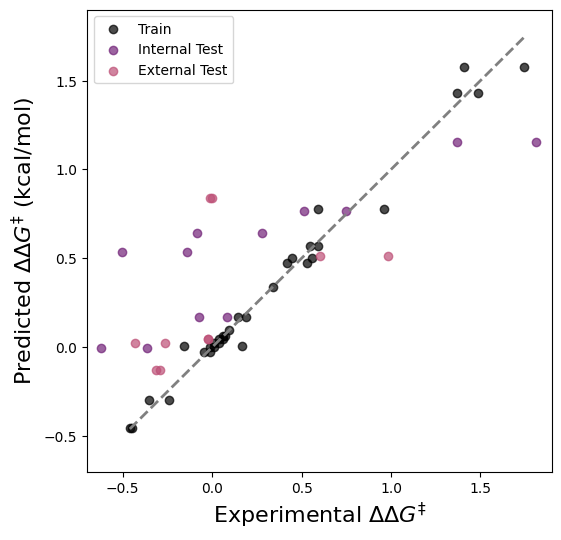

In [5]:
# the feature selection is based on SelectKBest, it is performed on the training set. 

def select_k_best_features(X_train, y_train, X_internal_test, y_internal_test, X_external_test, y_external_test, k, scoring_function=f_regression, regressor=KNeighborsRegressor(n_neighbors=10, weights='distance' , p=1), plot=True):
    """
    Select the k best features based on the specified scoring function and regressor.
    Parameters:
    X_train (pd.DataFrame): Training feature set.
    y_train (pd.Series): Training target variable.
    X_internal_test (pd.DataFrame): Internal test feature set.
    y_internal_test (pd.Series): Internal test target variable.
    X_external_test (pd.DataFrame): External test feature set.
    y_external_test (pd.Series): External test target variable.
    k (int): Number of top features to select.
    scoring_function (function): Scoring function to evaluate the features (default: f_regression).
    regressor (sklearn regressor): Regressor to evaluate the selected features (default: KNeighborsRegressor).
    plot (bool): Whether to plot the predicted vs experimental values (default: True).
    Returns:
    tuple: A tuple containing the selected feature names, R2 scores, and MAE scores for the training, internal test, and external test sets.
    """

    # define selector and select the k best features on the training set
    selector = SelectKBest(score_func=scoring_function, k=k) 
    X_train_selected = selector.fit_transform(X_train, y_train)

    # transform the internal and external test sets using the same selector
    X_internal_test_selected = selector.transform(X_internal_test)
    X_external_test_selected = selector.transform(X_external_test)

    selected_feature_indices = selector.get_support(indices=True)
    selected_feature_names = X_train.columns[selected_feature_indices]

    #print("Selected feature indices:", selected_feature_indices)
    if plot:
        print("Selected feature names:", selected_feature_names.tolist())

    # Fit the regressor on the training set with the selected features and evaluate on the training, internal test, and external test sets
    regressor.fit(X_train_selected, y_train)

    y_train_pred = regressor.predict(X_train_selected)
    y_internal_test_pred = regressor.predict(X_internal_test_selected)
    y_external_test_pred = regressor.predict(X_external_test_selected)

    r2_train = r2_score(y_train, y_train_pred)
    r2_internal_test = r2_score(y_internal_test, y_internal_test_pred)
    r2_external_test = r2_score(y_external_test, y_external_test_pred)

    mae_train = np.mean(np.abs(y_train - y_train_pred))
    mae_internal_test = np.mean(np.abs(y_internal_test - y_internal_test_pred))
    mae_external_test = np.mean(np.abs(y_external_test - y_external_test_pred))

    # plot 
    if plot:
        print (f"R2 train: {round(r2_train, 2)}, internal test: {round(r2_internal_test, 2)}, external test: {round(r2_external_test, 2)}")
        print (f"MAE train: {round(mae_train, 2)}, internal test: {round(mae_internal_test, 2)}, external test: {round(mae_external_test, 2)}")
        # plot the predicted vs experimental ddg values for the training, internal test, and external test sets
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=2, c='gray')

        ax.set_xlabel('Experimental $ΔΔG^{‡}$', fontsize=16)
        ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)', fontsize=16)
        ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
        ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Internal Test', alpha=0.7)
        ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='External Test', alpha=0.7)
        ax.set_xlim(-0.7, 1.9)
        ax.set_ylim(-0.7, 1.9)
        ax.legend()

        plt.show()

    return selected_feature_names.tolist(), (r2_train, r2_internal_test, r2_external_test), (mae_train, mae_internal_test, mae_external_test)

def parity_plot_for_best_model(model_info, ax, label):
    """Helper tool, to plot the parity plot for the best model based on the internal test R2 or MAE scores."""
    k_best, fitted_regressor, scoring_function, _, r2_scores, mae_scores = model_info

    selector = SelectKBest(score_func=scoring_function, k=k_best)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_internal_sel = selector.transform(X_internal_test)
    X_external_sel = selector.transform(X_external_test)

    model = fitted_regressor.__class__(**fitted_regressor.get_params())
    model.fit(X_train_sel, y_train)

    y_train_pred = model.predict(X_train_sel)
    y_internal_pred = model.predict(X_internal_sel)
    y_external_pred = model.predict(X_external_sel)

    y_all = np.concatenate([y_train.values, y_internal_test.values, y_external_test.values])
    y_min, y_max = y_all.min(), y_all.max()
    pad = 0.05 * (y_max - y_min)

    ax.plot([y_min - pad, y_max + pad], [y_min - pad, y_max + pad], '--', lw=2, c='gray')
    ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
    ax.scatter(y_internal_test, y_internal_pred, color='#722378', label='Internal Test', alpha=0.7)
    ax.scatter(y_external_test, y_external_pred, color='#BD5077', label='External Test', alpha=0.7)

    ax.set_xlabel('Experimental $ΔΔG^{‡}$')
    ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)')
    ax.set_xlim(y_min - pad, y_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(
        f"{label}\n{k_best} features | {model.__class__.__name__} | {scoring_function.__name__}\n"
        f"Val R²={r2_scores[1]:.2f}, Val MAE={mae_scores[1]:.2f}"
    )
    ax.legend()
    
# usage on one example with KNN regressor and f_regression as scoring function
k = 5
regressor = KNeighborsRegressor(n_neighbors=10, weights='distance' , p=1)
scoring_function = f_regression
selected_features, r2_scores, mae_scores = select_k_best_features(X_train, y_train, X_internal_test, y_internal_test, X_external_test, y_external_test, k, scoring_function, regressor)

Shape of descriptors file before removing parameters with r^2 > 0.7 : (32, 521)
Shape of descriptors file after removing parameters with R^2 > 0.7 :  (32, 20)
Best model based on R2 internal test: k=7, regressor=KNeighborsRegressor, scoring_function=mutual_info_regression, 
7 features selected: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'dihedral_F1_Ni_N1_C1(°)_Boltz', 'Sterimol_L_N1_Ni(Å)_morfeus_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_Boltz', 'Sterimol_L_N2_Ni(Å)_morfeus_Boltz', 'Hirsh_atom_dipole_C2_Boltz'], 
r2_scores=[0.98, 0.8, 0.26], 
mae_scores=[np.float64(0.05), np.float64(0.25), np.float64(0.28)]
Best model based on MAE internal test: k=7, regressor=KNeighborsRegressor, scoring_function=mutual_info_regression, 
7 features selected: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'dihedral_F1_Ni_N1_C1(°)_Boltz', 'Sterimol_L_N1_Ni(Å)_morfeus_Boltz', 'Sterimol_L_C1_N1(Å)_morfeus_Boltz', 'Sterimol_L_N2_Ni(Å)_morfeus_Boltz', 'Hirsh_atom_dipole_C2_Boltz'], 
r2_scores=[0.98, 0.8, 0.26], 
mae_scores=[

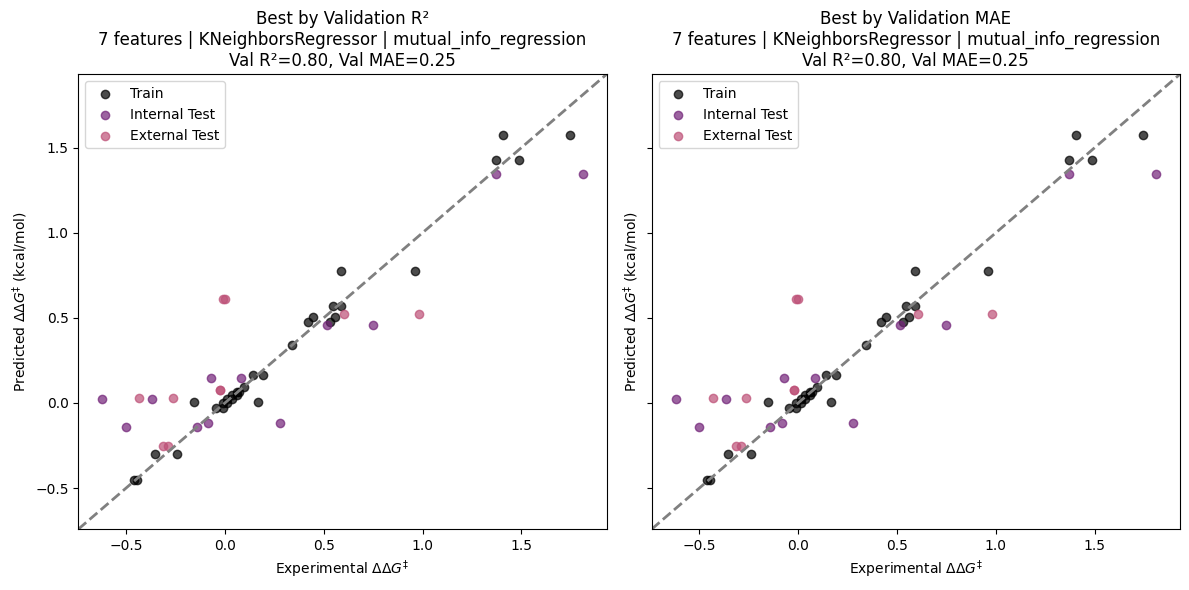

In [6]:
# iterative search for the best k value and models hyperparameters can be added as well, e.g. n_neighbors for KNN, alpha for Ridge, etc.
threshold = 0.7
scaler    = StandardScaler()
X_train, y_train, y_train_labels, X_internal_test, y_internal_test, y_internal_test_labels, X_external_test, y_external_test, y_external_test_labels = preprocess_data(df, threshold=threshold, scaler=scaler)

k_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
regressors = [KNeighborsRegressor(n_neighbors=1+2*i, weights='distance' , p=1) for i in range(0, 6)] + [Ridge(alpha=0.1), Ridge(alpha=1), Ridge(alpha=10)] + [KernelRidge(alpha=0.1, kernel='rbf'), KernelRidge(alpha=1, kernel='rbf'), KernelRidge(alpha=10, kernel='rbf')]
scoring_functions = [f_regression, mutual_info_regression]

best_model_r2_kbest = None
best_model_mae_kbest = None
best_r2_internal_test = -np.inf
best_mae_internal_test = np.inf
for k in k_list:
    for regressor in regressors:
        for scoring_function in scoring_functions:
            #print(f"Evaluating model with k={k}, regressor={regressor.__class__.__name__}, scoring_function={scoring_function.__name__}")
            selected_features, r2_scores, mae_scores = select_k_best_features(X_train, y_train, X_internal_test, y_internal_test, X_external_test, y_external_test, k, scoring_function, regressor, plot=False)
            r2_train, r2_internal_test, r2_external_test = r2_scores
            mae_train, mae_internal_test, mae_external_test = mae_scores
            
            if r2_internal_test > best_r2_internal_test:
                best_r2_internal_test = r2_internal_test
                best_model_r2_kbest = (k, regressor, scoring_function, selected_features, r2_scores, mae_scores)

            if mae_internal_test < best_mae_internal_test:
                best_mae_internal_test = mae_internal_test
                best_model_mae_kbest = (k, regressor, scoring_function, selected_features, r2_scores, mae_scores)

print(f"Best model based on R2 internal test: k={best_model_r2_kbest[0]}, regressor={best_model_r2_kbest[1].__class__.__name__}, scoring_function={best_model_r2_kbest[2].__name__}, \n{len(best_model_r2_kbest[3])} features selected: {best_model_r2_kbest[3]}, \nr2_scores={[round(x,2) for x in best_model_r2_kbest[4]]}, \nmae_scores={[round(x,2) for x in best_model_r2_kbest[5]]}")
print(f"Best model based on MAE internal test: k={best_model_mae_kbest[0]}, regressor={best_model_mae_kbest[1].__class__.__name__}, scoring_function={best_model_mae_kbest[2].__name__}, \n{len(best_model_mae_kbest[3])} features selected: {best_model_mae_kbest[3]}, \nr2_scores={[round(x,2) for x in best_model_mae_kbest[4]]}, \nmae_scores={[round(x,2) for x in best_model_mae_kbest[5]]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

parity_plot_for_best_model(best_model_r2_kbest, axes[0], 'Best by Validation R²')
parity_plot_for_best_model(best_model_mae_kbest, axes[1], 'Best by Validation MAE')

plt.tight_layout()
plt.show()

Best model based on R2 internal test: k=7, regressor=KNeighborsRegressor, scoring_function=mutual_info_regression, 
 7 features selected: ['%Vbur_Ni_2.0Å_Boltz', '%Vbur_C1_3.0Å_min', '%Vbur_N2_4.5Å_min', '%Vbur_N1_5.0Å_min', '%Vbur_N2_5.0Å_min', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_Boltz', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_low_E'], 
r2_scores=(0.9784962556584856, 0.8369476319521152, 0.543904023888134), 
mae_scores=(np.float64(0.05343460494215957), np.float64(0.240291378878602), np.float64(0.2336067790450167))
Best model based on MAE internal test: k=9, regressor=KNeighborsRegressor, scoring_function=mutual_info_regression, 
9 features selected: ['NBO_charge_N1_max', '%Vbur_Ni_2.0Å_Boltz', '%Vbur_C1_3.0Å_min', '%Vbur_N2_4.5Å_min', '%Vbur_N1_5.0Å_min', '%Vbur_N2_5.0Å_min', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_Boltz', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_low_E', 'Hirsh_CM5_charge_C2_Boltz'], 
r2_scores=(0.9784962556584856, 0.8359736026338144, 0.16521096049392048), 
mae_scores=(np.float64(0.05343460494

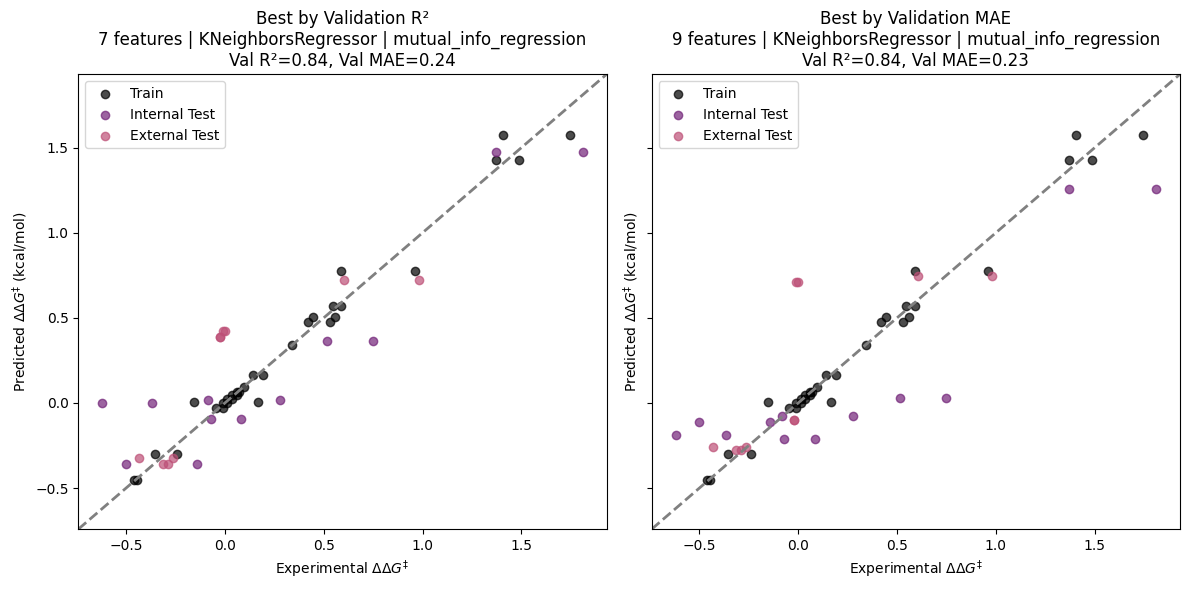

In [7]:
# iterative search for the best k value and models hyperparameters can be added as well, e.g. n_neighbors for KNN, alpha for Ridge, etc.
threshold = None
scaler    = StandardScaler()
X_train, y_train, y_train_labels, X_internal_test, y_internal_test, y_internal_test_labels, X_external_test, y_external_test, y_external_test_labels = preprocess_data(df, threshold=threshold, scaler=scaler)

k_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
regressors = [KNeighborsRegressor(n_neighbors=1+2*i, weights='distance' , p=1) for i in range(0, 6)] + [Ridge(alpha=0.1), Ridge(alpha=1), Ridge(alpha=10)] + [KernelRidge(alpha=0.1, kernel='rbf'), KernelRidge(alpha=1, kernel='rbf'), KernelRidge(alpha=10, kernel='rbf')]
scoring_functions = [f_regression, mutual_info_regression]

best_model_r2_kbest_no_threshold = None
best_model_mae_kbest_no_threshold = None
best_r2_internal_test = -np.inf
best_mae_internal_test = np.inf
for k in k_list:
    for regressor in regressors:
        for scoring_function in scoring_functions:
            #print(f"Evaluating model with k={k}, regressor={regressor.__class__.__name__}, scoring_function={scoring_function.__name__}")
            selected_features, r2_scores, mae_scores = select_k_best_features(X_train, y_train, X_internal_test, y_internal_test, X_external_test, y_external_test, k, scoring_function, regressor, plot=False)
            r2_train, r2_internal_test, r2_external_test = r2_scores
            mae_train, mae_internal_test, mae_external_test = mae_scores
            
            if r2_internal_test > best_r2_internal_test:
                best_r2_internal_test = r2_internal_test
                best_model_r2_kbest_no_threshold = (k, regressor, scoring_function, selected_features, r2_scores, mae_scores)

            if mae_internal_test < best_mae_internal_test:
                best_mae_internal_test = mae_internal_test
                best_model_mae_kbest_no_threshold = (k, regressor, scoring_function, selected_features, r2_scores, mae_scores)

print(f"Best model based on R2 internal test: k={best_model_r2_kbest_no_threshold[0]}, regressor={best_model_r2_kbest_no_threshold[1].__class__.__name__}, scoring_function={best_model_r2_kbest_no_threshold[2].__name__}, \n {len(best_model_r2_kbest_no_threshold[3])} features selected: {best_model_r2_kbest_no_threshold[3]}, \nr2_scores={best_model_r2_kbest_no_threshold[4]}, \nmae_scores={best_model_r2_kbest_no_threshold[5]}")
print(f"Best model based on MAE internal test: k={best_model_mae_kbest_no_threshold[0]}, regressor={best_model_mae_kbest_no_threshold[1].__class__.__name__}, scoring_function={best_model_mae_kbest_no_threshold[2].__name__}, \n{len(best_model_mae_kbest_no_threshold[3])} features selected: {best_model_mae_kbest_no_threshold[3]}, \nr2_scores={best_model_mae_kbest_no_threshold[4]}, \nmae_scores={best_model_mae_kbest_no_threshold[5]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

parity_plot_for_best_model(best_model_r2_kbest_no_threshold, axes[0], 'Best by Validation R²')
parity_plot_for_best_model(best_model_mae_kbest_no_threshold, axes[1], 'Best by Validation MAE')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning


##### Selection of best features using RFECV

Optimal number of features: 3
Selected feature names: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'dihedral_F1_Ni_N1_C1(°)_max']
Selected features: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'dihedral_F1_Ni_N1_C1(°)_max']
R2 Train: 0.84, R2 Validation: 0.61, R2 Test: 0.09
MAE Train: 0.17, MAE Validation: 0.38 MAE Test: 0.29


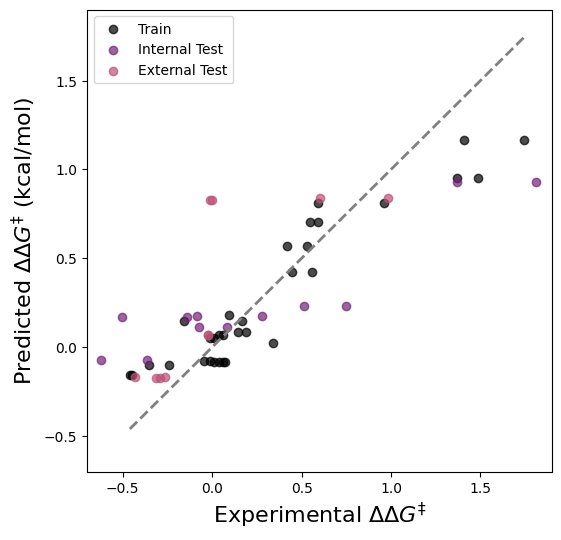

Optimal number of features: 8
Selected feature names: ['HOMO_Boltz', 'HOMO_max', 'η_max', 'η_low_E', 'Sterimol_B1_C2_N2(Å)_morfeus_min', 'Sterimol_B1_Ni_N2(Å)_morfeus_max', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min', '%Vbur_Ni_octant_–,–,–_Boltz']
Selected features: ['HOMO_Boltz', 'HOMO_max', 'η_max', 'η_low_E', 'Sterimol_B1_C2_N2(Å)_morfeus_min', 'Sterimol_B1_Ni_N2(Å)_morfeus_max', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min', '%Vbur_Ni_octant_–,–,–_Boltz']
R2 Train: 0.91, R2 Validation: 0.65, R2 Test: 0.68
MAE Train: 0.11, MAE Validation: 0.36 MAE Test: 0.17


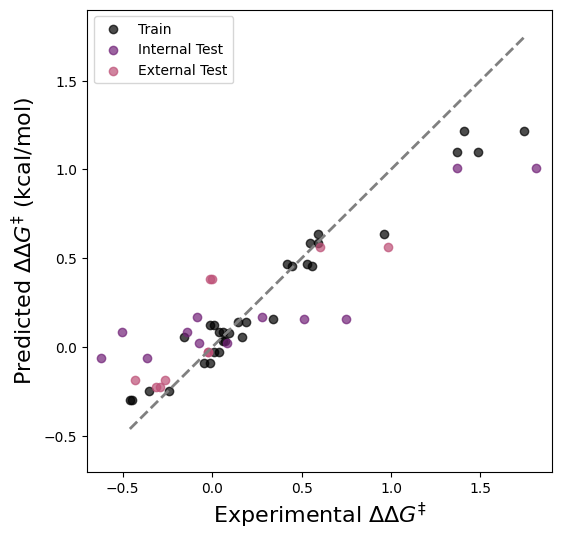

In [8]:
def rfecv_feature_selection(df, threshold=None, scaler=None, 
                            rfecv_reg=Ridge(alpha=0.3), rfecv_step=1, rfecv_cv=KFold(5, shuffle=True, random_state=42), rfecv_scoring='neg_mean_squared_error', rfecv_min_features_to_select=2,
                            fit_regressor=KernelRidge(kernel='rbf', alpha=0.7),  
                            plot=True):
    """
    Perform feature selection using Recursive Feature Elimination with Cross-Validation (RFECV) and evaluate the performance of a specified regressor on the selected features.
    Parameters:
        # preprocess the data
    df (pd.DataFrame): The input dataframe containing the features and target variable.
    threshold (float): The threshold for removing collinear features based on R^2, if threshold is None, no features will be removed.
    scaler (sklearn.preprocessing.StandardScaler): The scaler to standardize the features.
        # RFECV parameters
    rfecv_reg (sklearn regressor): The regressor to use for RFECV (default: Ridge(alpha=0.3)).
    rfecv_step (int): The number of features to remove at each iteration of RFECV (default: 1).
    rfecv_cv (sklearn.model_selection.KFold): The cross-validation strategy for RFECV (default: KFold(5, shuffle=True, random_state=42)).
    rfecv_scoring (str): The scoring metric for RFECV (default: 'neg_mean_squared_error').
    rfecv_min_features_to_select (int): The minimum number of features to select with RFECV (default: 2).
        # Regressor fitting and evaluation
    fit_regressor (sklearn regressor): The regressor to fit on the selected features and evaluate performance (default: KernelRidge(kernel='rbf', alpha=0.7)).
        # plot
    plot (bool): Whether to plot the predicted vs experimental values for the training, internal test, and external test sets (default: True).
    Returns:
    tuple: A tuple containing the selected feature names, R2 scores, and MAE scores for the training, internal test, and external test sets."""

    # preprocess the data
    X_train, y_train, _, X_internal_test, y_internal_test, _ , X_external_test, y_external_test, _ = preprocess_data(df, threshold=threshold, scaler=scaler, silent=True)

    rfecv = RFECV(
        estimator=rfecv_reg,
        step=rfecv_step,
        cv=rfecv_cv,
        scoring=rfecv_scoring,        
        min_features_to_select=rfecv_min_features_to_select)
    
    X_train_selected = rfecv.fit_transform(X_train, y_train)
    X_internal_test_selected = rfecv.transform(X_internal_test)
    X_external_test_selected= rfecv.transform(X_external_test)

    selected_mask = rfecv.support_
    selected_features = X_train.columns[selected_mask]

    if plot:
        print("Optimal number of features:", rfecv.n_features_)
        print("Selected feature names:", selected_features.tolist())
        print(f"Selected features: {selected_features.tolist()}")


    fit_regressor.fit(X_train_selected, y_train)
    y_train_pred = fit_regressor.predict(X_train_selected)
    y_internal_test_pred = fit_regressor.predict(X_internal_test_selected)
    y_external_test_pred = fit_regressor.predict(X_external_test_selected)

    r2_train = r2_score(y_train, y_train_pred)
    r2_internal_test = r2_score(y_internal_test, y_internal_test_pred)
    r2_external_test = r2_score(y_external_test, y_external_test_pred)

    mae_train = np.mean(np.abs(y_train - y_train_pred))
    mae_internal_test = np.mean(np.abs(y_internal_test - y_internal_test_pred))
    mae_external_test = np.mean(np.abs(y_external_test - y_external_test_pred))
    
    if plot:
        print (f"R2 Train: {round(r2_train, 2)}, R2 Validation: {round(r2_internal_test, 2)}, R2 Test: {round(r2_external_test, 2)}")
        print (f"MAE Train: {round(mae_train, 2)}, MAE Validation: {round(mae_internal_test, 2)}", f"MAE Test: {round(mae_external_test, 2)}")
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=2, c='gray')
        ax.set_xlabel('Experimental $ΔΔG^{‡}$', fontsize=16)
        ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)', fontsize=16)
        ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
        ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Internal Test', alpha=0.7)
        ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='External Test', alpha=0.7)
        ax.set_xlim(-0.7, 1.9)
        ax.set_ylim(-0.7, 1.9)
        ax.legend()
        plt.show()

    return selected_features.tolist(), (r2_train, r2_internal_test, r2_external_test), (mae_train, mae_internal_test, mae_external_test)

# usage example
selected_features, r2_scores, mae_scores = rfecv_feature_selection(df, threshold=0.7, scaler=StandardScaler(), 
                                                                   rfecv_reg=Ridge(alpha=0.3), 
                                                                   rfecv_step=1, rfecv_cv=KFold(5, shuffle=True, random_state=42), 
                                                                   rfecv_scoring='neg_mean_squared_error', 
                                                                   rfecv_min_features_to_select=2, 
                                                                   fit_regressor=KernelRidge(kernel='rbf', alpha=0.7), 
                                                                   plot=True)

selected_features, r2_scores, mae_scores = rfecv_feature_selection(df, threshold=None, scaler=StandardScaler(), 
                                                                   rfecv_reg=Ridge(alpha=0.3), 
                                                                   rfecv_step=1, rfecv_cv=KFold(5, shuffle=True, random_state=42), 
                                                                   rfecv_scoring='neg_mean_squared_error', 
                                                                   rfecv_min_features_to_select=2, 
                                                                   fit_regressor=KernelRidge(kernel='rbf', alpha=0.7), 
                                                                   plot=True)

In [9]:
from tqdm.notebook import tqdm

# Grid search over RFECV feature selection parameters
thresholds = [None, 0.7]
rfecv_regs = [Ridge(alpha=a) for a in [0.1, 0.3, 0.5, 1.0]]
rfecv_steps = [1, 2]
rfecv_min_features = [2, 3, 4, 5]
fit_regressors = (
    [KernelRidge(kernel='rbf', alpha=a) for a in [0.1, 0.5, 0.7, 1.0]] +
    [KernelRidge(kernel='polynomial', alpha=a) for a in [0.5, 1.0]] +
    [Ridge(alpha=a) for a in [0.1, 1.0]] #+
    #[KNeighborsRegressor(n_neighbors=n, weights='distance', p=1) for n in [3, 5, 7]]
)

best_model_r2_rfecv = None
best_model_mae_rfecv = None
best_r2_val = -np.inf
best_mae_val = np.inf
total = len(thresholds) * len(rfecv_regs) * len(rfecv_steps) * len(rfecv_min_features) * len(fit_regressors)

from itertools import product
param_grid = list(product(thresholds, rfecv_regs, rfecv_steps, rfecv_min_features, fit_regressors))

for threshold, rfecv_reg, step, min_feat, fit_reg in tqdm(param_grid, total=total, desc="RFECV grid search"):
    try:
        feats, r2s, maes = rfecv_feature_selection(
            df, threshold=threshold, scaler=StandardScaler(),
            rfecv_reg=rfecv_reg, rfecv_step=step,
            rfecv_cv=KFold(5, shuffle=True, random_state=42),
            rfecv_scoring='neg_mean_squared_error',
            rfecv_min_features_to_select=min_feat,
            fit_regressor=fit_reg, plot=False)
    except Exception:
        continue

    r2_train, r2_val, r2_test = r2s
    mae_train, mae_val, mae_test = maes

    config = {
        'threshold': threshold,
        'rfecv_reg': rfecv_reg,
        'rfecv_step': step,
        'min_features': min_feat,
        'fit_regressor': fit_reg,
        'features': feats,
        'r2_scores': r2s,
        'mae_scores': maes,
    }

    if r2_val > best_r2_val:
        best_r2_val = r2_val
        best_model_r2_rfecv = config

    if mae_val < best_mae_val:
        best_mae_val = mae_val
        best_model_mae_rfecv = config

print(f"\nEvaluated {total} configurations\n")

for label, best in [("Best by Validation R²", best_model_r2_rfecv), ("Best by Validation MAE", best_model_mae_rfecv)]:
    if best is None:
        continue
    print(f"--- {label} ---")
    print(f"  threshold={best['threshold']}, rfecv_reg={best['rfecv_reg']}, step={best['rfecv_step']}, min_features={best['min_features']}")
    print(f"  fit_regressor={best['fit_regressor']}")
    print(f"  {len(best['features'])} features: {best['features']}")
    print(f"  R² (train, val, test): {[round(x,3) for x in best['r2_scores']]}")
    print(f"  MAE (train, val, test): {[round(x,3) for x in best['mae_scores']]}\n")



RFECV grid search:   0%|          | 0/512 [00:00<?, ?it/s]


Evaluated 512 configurations

--- Best by Validation R² ---
  threshold=0.7, rfecv_reg=Ridge(alpha=0.5), step=1, min_features=2
  fit_regressor=KernelRidge(alpha=0.1, kernel='rbf')
  5 features: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'SASA_sphericity_Boltz', 'dihedral_F1_Ni_N1_C1(°)_min', '%Vbur_Ni_octant_+,–,–_Boltz']
  R² (train, val, test): [0.973, 0.826, 0.138]
  MAE (train, val, test): [np.float64(0.062), np.float64(0.25), np.float64(0.282)]

--- Best by Validation MAE ---
  threshold=0.7, rfecv_reg=Ridge(alpha=0.5), step=1, min_features=2
  fit_regressor=KernelRidge(alpha=0.1, kernel='rbf')
  5 features: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'SASA_sphericity_Boltz', 'dihedral_F1_Ni_N1_C1(°)_min', '%Vbur_Ni_octant_+,–,–_Boltz']
  R² (train, val, test): [0.973, 0.826, 0.138]
  MAE (train, val, test): [np.float64(0.062), np.float64(0.25), np.float64(0.282)]



Best RFECV model: 5 features, R² (train, val, test): [0.973, 0.826, 0.138], MAE (train, val, test): [np.float64(0.062), np.float64(0.25), np.float64(0.282)]


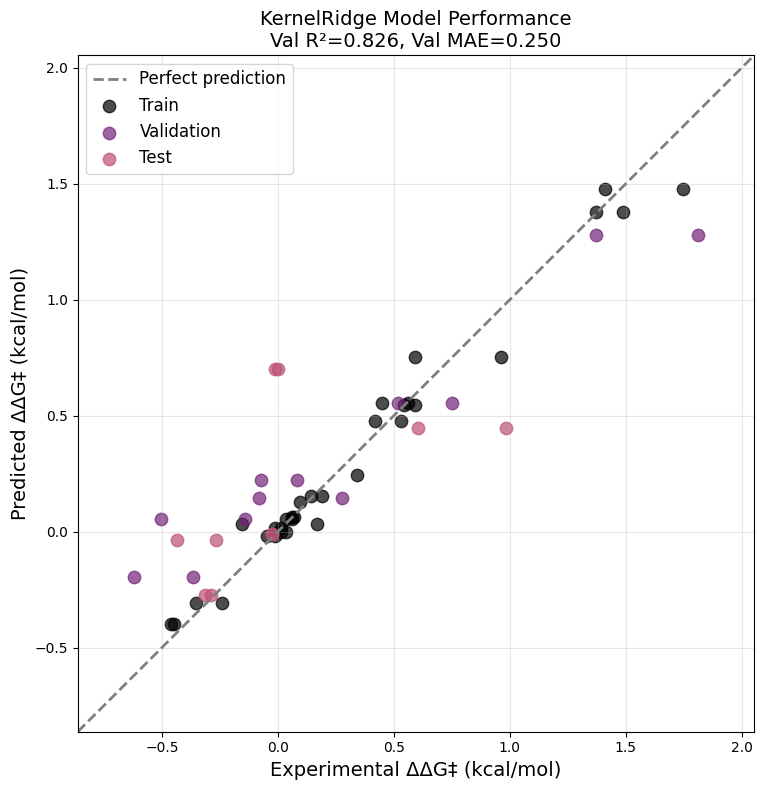

In [10]:
def parity_plot_for_rfecv_model(best_model_r2, df):

    # Preprocess data with best threshold
    X_train, y_train, _, X_internal_test, y_internal_test, _, X_external_test, y_external_test, _ = preprocess_data(
        df, threshold=best_model_r2['threshold'], scaler=StandardScaler(), silent=True
    )

    # Apply feature selection using RFECV with best parameters
    rfecv = RFECV(
        estimator=best_model_r2['rfecv_reg'],
        step=best_model_r2['rfecv_step'],
        cv=KFold(5, shuffle=True, random_state=42),
        scoring='neg_mean_squared_error',
        min_features_to_select=best_model_r2['min_features']
    )

    X_train_sel = rfecv.fit_transform(X_train, y_train)
    X_internal_test_sel = rfecv.transform(X_internal_test)
    X_external_test_sel = rfecv.transform(X_external_test)

    # Train model with best regressor
    best_regressor = best_model_r2['fit_regressor']
    best_regressor.fit(X_train_sel, y_train)

    # Generate predictions
    y_train_pred = best_regressor.predict(X_train_sel)
    y_internal_test_pred = best_regressor.predict(X_internal_test_sel)
    y_external_test_pred = best_regressor.predict(X_external_test_sel)

    print(f"Best RFECV model: {len(best_model_r2['features'])} features, R² (train, val, test): {[round(x,3) for x in best_model_r2['r2_scores']]}, MAE (train, val, test): {[round(x,3) for x in best_model_r2['mae_scores']]}")

    # Create parity plot
    fig, ax = plt.subplots(figsize=(8, 8))

    y_all = np.concatenate([y_train.values, y_internal_test.values, y_external_test.values])
    y_min, y_max = y_all.min(), y_all.max()
    pad = 0.1 * (y_max - y_min)

    ax.plot([y_min - pad, y_max + pad], [y_min - pad, y_max + pad], '--', lw=2, c='gray', label='Perfect prediction')
    ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7, s=80)
    ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Validation', alpha=0.7, s=80)
    ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='Test', alpha=0.7, s=80)

    ax.set_xlabel('Experimental ΔΔG‡ (kcal/mol)', fontsize=14)
    ax.set_ylabel('Predicted ΔΔG‡ (kcal/mol)', fontsize=14)
    ax.set_xlim(y_min - pad, y_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_aspect('equal')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.title(f'KernelRidge Model Performance\nVal R²={best_model_r2["r2_scores"][1]:.3f}, Val MAE={best_model_r2["mae_scores"][1]:.3f}', fontsize=14)
    plt.tight_layout()
    plt.show()

parity_plot_for_rfecv_model(best_model_r2_rfecv, df)

#### Selection of best features using RFE + Hyperparameter tuning

Optimal number of features: 4
Selected feature names: ['HOMO_Boltz', 'η_low_E', 'Sterimol_B1_Ni_N2(Å)_morfeus_max', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min']
Selected features: ['HOMO_Boltz', 'η_low_E', 'Sterimol_B1_Ni_N2(Å)_morfeus_max', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min']
R2 Train: 0.97, R2 Validation: 0.81, R2 Test: 0.75
MAE Train: 0.06, MAE Validation: 0.24 MAE Test: 0.16


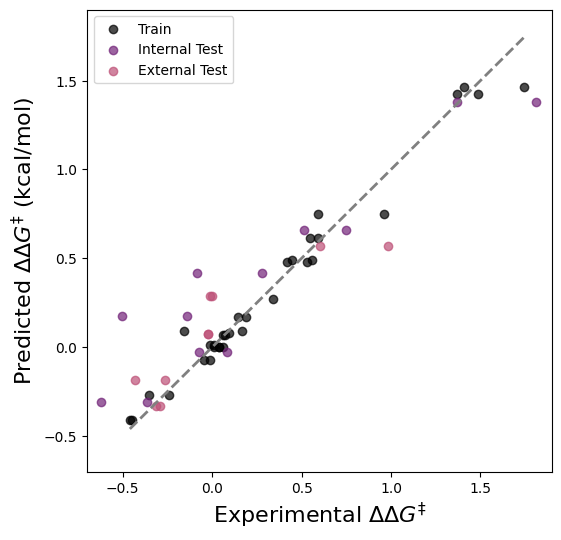

Optimal number of features: 4
Selected feature names: ['HOMO_Boltz', 'η_low_E', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min', 'Sterimol_B1_Ni_N2(Å)_morfeus_max']
Selected features: ['HOMO_Boltz', 'η_low_E', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min', 'Sterimol_B1_Ni_N2(Å)_morfeus_max']
R2 Train: 0.97, R2 Validation: 0.81, R2 Test: 0.75
MAE Train: 0.06, MAE Validation: 0.24 MAE Test: 0.16


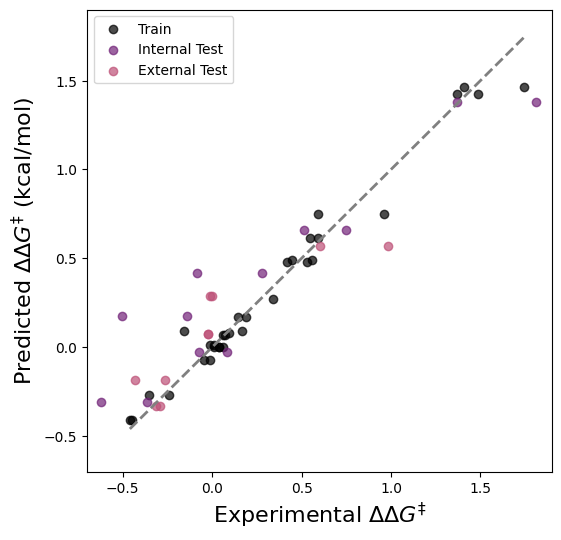

In [20]:
def rfe_feature_selection(df, threshold=None, scaler=None, 
                            rfecv_reg=Ridge(alpha=0.3), rfecv_step=1, rfecv_min_features_to_select=4,
                            fit_regressor=KernelRidge(kernel='polynomial', alpha=0.7), 
                            shuffle=False, random_state=42, 
                            plot=True):
    """
    Perform feature selection using Recursive Feature Elimination with Cross-Validation (RFECV) and evaluate the performance of a specified regressor on the selected features.
    Parameters:
        # preprocess the data
    df (pd.DataFrame): The input dataframe containing the features and target variable.
    threshold (float): The threshold for removing collinear features based on R^2, if threshold is None, no features will be removed.
    scaler (sklearn.preprocessing.StandardScaler): The scaler to standardize the features.
        # RFECV parameters
    rfecv_reg (sklearn regressor): The regressor to use for RFECV (default: Ridge(alpha=0.3)).
    rfecv_step (int): The number of features to remove at each iteration of RFECV (default: 1).
    rfecv_min_features_to_select (int): The minimum number of features to select with RFECV (default: 2).
        # Regressor fitting and evaluation
    fit_regressor (sklearn regressor): The regressor to fit on the selected features and evaluate performance (default: KernelRidge(kernel='rbf', alpha=0.7)).
        # shuffle and random state
    shuffle (bool): Whether to shuffle the data before splitting (default: False).
    random_state (int): The random seed for reproducibility (default: 42).
        # plot
    plot (bool): Whether to plot the predicted vs experimental values for the training, internal test, and external test sets (default: True).
    Returns:
    tuple: A tuple containing the selected feature names, R2 scores, and MAE scores for the training, internal test, and external test sets."""

    # preprocess the data
    X_train, y_train, _, X_internal_test, y_internal_test, _ , X_external_test, y_external_test, _ = preprocess_data(df, threshold=threshold, scaler=scaler, silent=True)
    
    # shuffle the data if specified
    if shuffle:
        rng = np.random.RandomState(42)
        shuffled_cols = rng.permutation(X_train.columns)
        X_train = X_train[shuffled_cols]
        X_internal_test = X_internal_test[shuffled_cols]
        X_external_test = X_external_test[shuffled_cols]

    rfecv = RFE(
        estimator=rfecv_reg,
        step=rfecv_step,
        n_features_to_select=rfecv_min_features_to_select)

    
    X_train_selected = rfecv.fit_transform(X_train, y_train)
    X_internal_test_selected = rfecv.transform(X_internal_test)
    X_external_test_selected= rfecv.transform(X_external_test)

    selected_mask = rfecv.support_
    selected_features = X_train.columns[selected_mask]

    if plot:
        print("Optimal number of features:", rfecv.n_features_)
        print("Selected feature names:", selected_features.tolist())
        print(f"Selected features: {selected_features.tolist()}")


    fit_regressor.fit(X_train_selected, y_train)
    y_train_pred = fit_regressor.predict(X_train_selected)
    y_internal_test_pred = fit_regressor.predict(X_internal_test_selected)
    y_external_test_pred = fit_regressor.predict(X_external_test_selected)

    r2_train = r2_score(y_train, y_train_pred)
    r2_internal_test = r2_score(y_internal_test, y_internal_test_pred)
    r2_external_test = r2_score(y_external_test, y_external_test_pred)

    mae_train = np.mean(np.abs(y_train - y_train_pred))
    mae_internal_test = np.mean(np.abs(y_internal_test - y_internal_test_pred))
    mae_external_test = np.mean(np.abs(y_external_test - y_external_test_pred))
    
    if plot:
        print (f"R2 Train: {round(r2_train, 2)}, R2 Validation: {round(r2_internal_test, 2)}, R2 Test: {round(r2_external_test, 2)}")
        print (f"MAE Train: {round(mae_train, 2)}, MAE Validation: {round(mae_internal_test, 2)}", f"MAE Test: {round(mae_external_test, 2)}")
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=2, c='gray')
        ax.set_xlabel('Experimental $ΔΔG^{‡}$', fontsize=16)
        ax.set_ylabel('Predicted $ΔΔG^{‡}$ (kcal/mol)', fontsize=16)
        ax.scatter(y_train, y_train_pred, color='black', label='Train', alpha=0.7)
        ax.scatter(y_internal_test, y_internal_test_pred, color='#722378', label='Internal Test', alpha=0.7)
        ax.scatter(y_external_test, y_external_test_pred, color='#BD5077', label='External Test', alpha=0.7)
        ax.set_xlim(-0.7, 1.9)
        ax.set_ylim(-0.7, 1.9)
        ax.legend()
        plt.show()

    return selected_features.tolist(), (r2_train, r2_internal_test, r2_external_test), (mae_train, mae_internal_test, mae_external_test)

# usage example
selected_features, r2_scores, mae_scores = rfe_feature_selection(df, scaler=StandardScaler())

selected_features, r2_scores, mae_scores = rfe_feature_selection(df, scaler=StandardScaler(), shuffle=True, random_state=1)

#### Hyperparameter tuning of the best model for RFE

In [21]:
X_train, y_train, y_train_labels, X_internal_test, y_internal_test, y_internal_test_labels, X_external_test, y_external_test, y_external_test_labels = preprocess_data(df, threshold=None, scaler=StandardScaler(), silent=True)

# Grid search over RFE feature selection parameters
thresholds = [None, 0.7]
rfecv_regs = [Ridge(alpha=a) for a in [0.1, 0.3, 0.5, 1.0]]
rfecv_steps = [1, 2]
rfecv_min_features = [2, 3, 4, 5]
fit_regressors = (
    [KernelRidge(kernel='rbf', alpha=a) for a in [0.1, 0.5, 0.7, 1.0]] +
    [KernelRidge(kernel='polynomial', alpha=a) for a in [0.1, 0.5, 0.7, 1.0]] +
    [Ridge(alpha=a) for a in [0.1, 0.5, 0.7, 1.0]] #+
    #[KNeighborsRegressor(n_neighbors=n, weights='distance', p=1) for n in [3, 5, 7]]
)

best_model_r2_rfe = None
best_model_mae_rfe = None
best_r2_val = -np.inf
best_mae_val = np.inf
total = len(thresholds) * len(rfecv_regs) * len(rfecv_steps) * len(rfecv_min_features) * len(fit_regressors)

from itertools import product
param_grid = list(product(thresholds, rfecv_regs, rfecv_steps, rfecv_min_features, fit_regressors))

for threshold, rfecv_reg, step, min_feat, fit_reg in tqdm(param_grid, total=total, desc="RFECV grid search"):
    try:
        feats, r2s, maes = rfe_feature_selection(
            df, threshold=threshold, scaler=StandardScaler(),
            rfecv_reg=rfecv_reg, rfecv_step=step,
            rfecv_min_features_to_select=min_feat,
            fit_regressor=fit_reg, plot=False)
    except Exception:
        continue

    r2_train, r2_val, r2_test = r2s
    mae_train, mae_val, mae_test = maes

    config = {
        'threshold': threshold,
        'rfecv_reg': rfecv_reg,
        'rfecv_step': step,
        'min_features': min_feat,
        'fit_regressor': fit_reg,
        'features': feats,
        'r2_scores': r2s,
        'mae_scores': maes,
    }

    if r2_val > best_r2_val:
        best_r2_val = r2_val
        best_model_r2_rfe = config

    if mae_val < best_mae_val:
        best_mae_val = mae_val
        best_model_mae_rfe = config

print(f"\nEvaluated {total} configurations\n")

for label, best in [("Best by Validation R²", best_model_r2_rfe), ("Best by Validation MAE", best_model_mae_rfe)]:
    if best is None:
        continue
    print(f"--- {label} ---")
    print(f"  threshold={best['threshold']}, rfecv_reg={best['rfecv_reg']}, step={best['rfecv_step']}, min_features={best['min_features']}")
    print(f"  fit_regressor={best['fit_regressor']}")
    print(f"  {len(best['features'])} features: {best['features']}")
    print(f"  R² (train, val, test): {[round(x,3) for x in best['r2_scores']]}")
    print(f"  MAE (train, val, test): {[round(x,3) for x in best['mae_scores']]}\n")


RFECV grid search:   0%|          | 0/768 [00:00<?, ?it/s]


Evaluated 768 configurations

--- Best by Validation R² ---
  threshold=0.7, rfecv_reg=Ridge(alpha=0.5), step=1, min_features=5
  fit_regressor=KernelRidge(alpha=0.1, kernel='rbf')
  5 features: ['LUMO_Boltz', 'dipole(Debye)_Boltz', 'SASA_sphericity_Boltz', 'dihedral_F1_Ni_N1_C1(°)_min', '%Vbur_Ni_octant_+,–,–_Boltz']
  R² (train, val, test): [0.973, 0.826, 0.138]
  MAE (train, val, test): [np.float64(0.062), np.float64(0.25), np.float64(0.282)]

--- Best by Validation MAE ---
  threshold=None, rfecv_reg=Ridge(alpha=0.3), step=1, min_features=4
  fit_regressor=KernelRidge(alpha=0.1, kernel='polynomial')
  4 features: ['HOMO_Boltz', 'η_low_E', 'Sterimol_B1_Ni_N2(Å)_morfeus_max', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min']
  R² (train, val, test): [0.977, 0.816, 0.736]
  MAE (train, val, test): [np.float64(0.056), np.float64(0.231), np.float64(0.174)]



Best RFECV model: 3 features, R² (train, val, test): [0.978, 0.874, 0.522], MAE (train, val, test): [np.float64(0.053), np.float64(0.206), np.float64(0.221)]


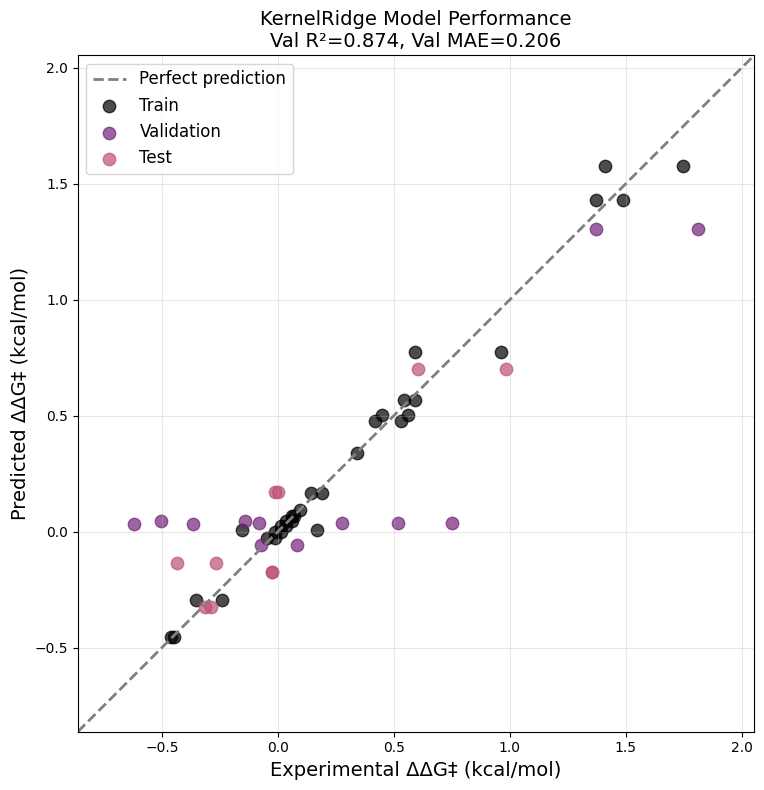

In [13]:
parity_plot_for_rfecv_model(best_model_r2_rfe, df)

### SHAP Analysis + Plot CS2

In [17]:
import shap 

X_train, y_train, y_train_labels, X_internal_test, y_internal_test, y_internal_test_labels, X_external_test, y_external_test, y_external_test_labels = preprocess_data(df, threshold=None, scaler=StandardScaler(), silent=True)

selected_ft = ['HOMO_Boltz', 'η_low_E', 'Sterimol_B1_Ni_N2(Å)_morfeus_max', 'Buried_Sterimol_B5_N1_Ni_5.0(Å)_min']
rfe_reg=Ridge(alpha=0.3)
rfe_step=1
rfe_min_features_to_select=4
fit_regressor=KernelRidge(kernel='polynomial', alpha=0.7)

X_selected = X_train[selected_ft]

model = fit_regressor
model.fit(X_selected, y_train)

background = shap.sample(X_selected, 100)  # or X.iloc[:100]
explainer  = shap.KernelExplainer(model.predict, background)
shap_values = explainer.shap_values(X_selected)
shap_values_test = explainer.shap_values(X_internal_test[selected_ft])

shap_values_df = pd.DataFrame(shap_values, columns=selected_ft)

shap_values_test_df = pd.DataFrame(shap_values_test, columns=selected_ft)

# drop any shape values that are all 0
cols_to_drop = [col for col in shap_values_df.columns if (shap_values_df[col] == 0).all()]
shap_values_df = shap_values_df.drop(columns=cols_to_drop)
shap_values_test_df = shap_values_test_df.drop(columns=cols_to_drop)

shap_t_test = shap_values_df.T
shap_t_test['SHAP_avg_val'] = shap_t_test.mean(axis=1)
shap_t_test

avg = shap_t_test.pop('SHAP_avg_val')
shap_t_test_abs = shap_t_test.abs()
shap_t_test_abs['SHAP_avg_abs_val'] = shap_t_test_abs.mean(axis=1)
avg_abs = shap_t_test_abs.pop('SHAP_avg_abs_val')
shap_t_test.insert(0, 'SHAP_avg_val', avg)
shap_t_test_abs.insert(1, 'SHAP_avg_abs_val', avg_abs)
shap_t_test_abs


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

,0,SHAP_avg_abs_val,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,28,29,30,31
HOMO_Boltz,0.244277,0.157457,0.244277,0.375729,0.228518,0.061544,0.061544,0.238883,0.238883,0.033022,...,0.161159,0.161159,0.225870,0.225870,0.003449,0.003449,0.529236,0.529236,0.265386,0.265386
η_low_E,0.138955,0.342976,0.138955,0.120525,0.141365,0.087542,0.087542,0.272365,0.272365,0.361595,...,0.316436,0.316436,0.635124,0.635124,0.403279,0.403279,0.181255,0.181255,0.349772,0.349772
Sterimol_B1_Ni_N2(Å)_morfeus_max,0.123997,0.197156,0.123997,0.153260,0.121308,0.096557,0.096557,0.146619,0.146619,0.169800,...,0.089597,0.089597,0.022740,0.022740,0.108936,0.108936,1.089754,1.089754,0.250458,0.250458
Buried_Sterimol_B5_N1_Ni_5.0(Å)_min,0.200231,0.261923,0.200231,0.145342,0.199676,0.062925,0.062925,0.517431,0.517431,0.081042,...,0.367943,0.367943,0.398449,0.398449,0.124988,0.124988,0.370778,0.370778,0.033074,0.033074


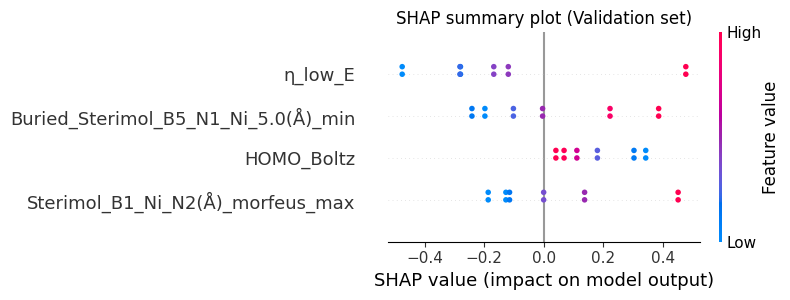

In [19]:
# SHAP summary plot for the validation set
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_test,
    X_internal_test[selected_ft],
    feature_names=selected_ft,
    show=False
)
plt.title("SHAP summary plot (Validation set)")
plt.tight_layout()
plt.show()